Perceptron de Rosenblatt:

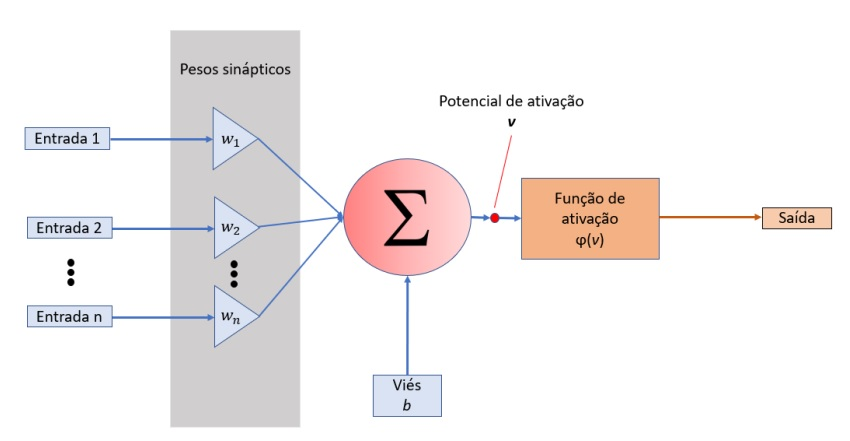 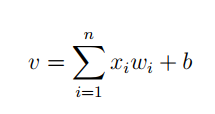

Rede Neural FeedForward MLP (Multilayer-Perceptron)

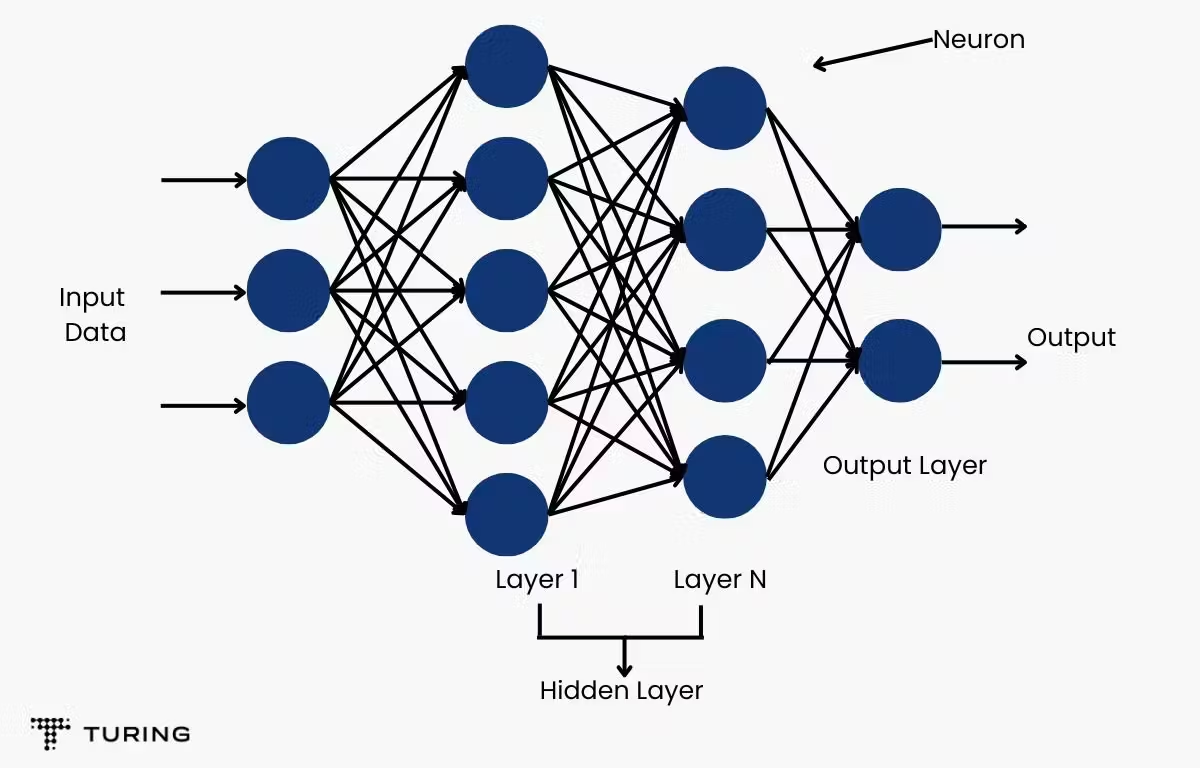

Bibliotecas


In [ ]:
import torch  #Modulo com a estrutura de dados para tensores 
import torch.nn as nn #Modulo para construção de redes neurais 
import torch.optim as optim #Modulo para implementar os algoritmos de otimização
from torch.utils.data import TensorDataset, DataLoader #Funções para manipulação dos dados 
import numpy as np #Algebra Linear, operações com vetores e algumas utilidades
import matplotlib.pyplot as plt #Para gráficos 
from sklearn.model_selection import train_test_split #Algoritmos para pré-processamento de dados, compararação de modelos, validação, ...

Exemplo 1: Ajuste de Curva/Regressão

In [ ]:
#Amostragem de um seno
x = np.linspace(0,2*np.pi,1000)
y = 2*np.sin(x)
plt.scatter(x,y)
plt.show()

In [ ]:
#Hold-out: Divisão do conjunto de dados entre dados para treinamento e dados para testes
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, shuffle= True)

#Construção dos Tensores
x_train, y_train = torch.Tensor(x_train).float(), torch.Tensor(y_train).float()
x_test, y_test = torch.Tensor(x_test).float(), torch.Tensor(y_test).float()

plt.scatter(x_test,y_test)
plt.show()

In [ ]:

#Criação da rede neural com 1 camada
class NN(nn.Module):
    def __init__(self,input_size, hidden_size, output_size):   #Inicialização 
        super(NN, self).__init__() #Inicializa os atributos da classe, sempre que uma nova instância do objeto é criada 
        self.layer1 = nn.Linear(input_size,hidden_size) #Camada de entrada >> Camada escondida
        self.Hidden1F = nn.Sigmoid() #Função de ativação da primeira camada escondida
        self.layer2 = nn.Linear(hidden_size,output_size)
    
    def forward(self,x): #FeedForward
        x = self.layer1(x)
        x = self.Hidden1F(x)
        x = self.layer2(x)
        return x

Algumas funções de ativação:

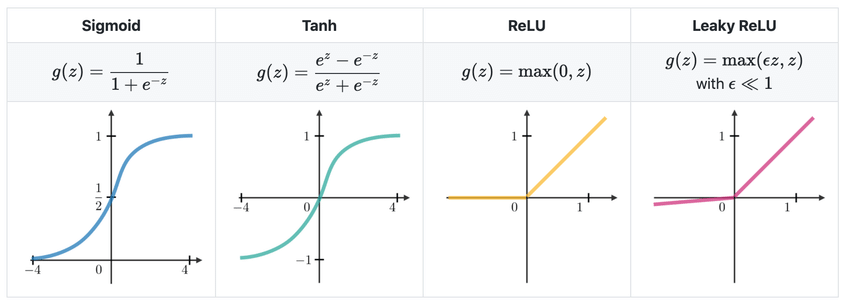

In [ ]:
#Definições e inicialização da rede

input_size = 1
hidden_size = 15
output_size = 1
model = NN(input_size,hidden_size,output_size)
print("Estrutura da RNA:")
print(model,"\n")

total_params = sum(p.numel() for p in model.parameters())

print("Numero total de parametros do modelo :",total_params)



>Regression Tasks (predicting continuous values):

    Mean Squared Error (MSE/L2 Loss): Calculates the average squared difference between predictions and targets. Heavily penalizes large errors.

    Mean Absolute Error (MAE/L1 Loss): Uses the average absolute difference, which is less sensitive to outliers than MSE.

>Classification Tasks (predicting discrete labels):

    Binary Cross-Entropy Loss: Used for binary classification (two classes), measuring the performance of a model whose output is a probability value between 0 and 1.

    Categorical Cross-Entropy Loss: Used for multi-class classification, often paired with a softmax activation in the output layer.

In [ ]:
#Definir a Função Custo/Função perda
LossF = nn.MSELoss()

#Definir o algoritmo de otimização
optimizer = optim.SGD(model.parameters(),lr=0.05, momentum=0.9)


Algumas operações com tensors:

>Mudança de Forma (Reshaping): .view() ou .reshape() altera as dimensões do tensor sem alterar seus dados.

>Indexação e Fatiamento (Slicing):  ex: tensor[0:2, :].

>Concatenar/Empilhar: torch.cat() junta tensores ao longo de uma dimensão.

>Operações Matemáticas: Adição, subtração, multiplicação (elemento a elemento ou matricial) são diretas: a + b, a * b, torch.matmul(a, b)

In [ ]:
#Regularização 
train_dataset = TensorDataset(x_train.view(-1,1),y_train.view(-1,1))
test_dataset = TensorDataset(x_test.view(-1,1),y_test.view(-1,1))

#Treinamento em batelada (Batch), On-line e Mini-batch.
train_loader = DataLoader(train_dataset, batch_size=900, shuffle=False)

num_epochs = 2000



#Treinamento por Backpropagation
losses = [] #Vetor para salvar o comportamento da função custo
model.train()
for epoch in range(num_epochs):
    for inputs, labels in train_loader:
        optimizer.zero_grad() #Zera o gradiente
        outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
        loss = LossF(outputs,labels) #Calcula o erro (Diferença entre a predição e a saída do dado)
        loss.backward() #Faz a retroprogação do erro e calcula o gradiente em relação a cada parâmetro do modelo
        optimizer.step() #Atualiza os parâmetros(Pesos e vieses) com base no gradiente e a taxa de aprendizado
    losses.append(loss.item()) 
    
    
plt.title('loss')
plt.plot(losses)
plt.show()



In [ ]:
#Salvar e carregar o modelo
#import torchvision.models as models
#Salvar >> torch.save(model, 'model.pth')
#Carregar  >>  model = torch.load('model.pth', weights_only=False)

model.eval()
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
with torch.no_grad(): # Disable gradient computation
    for inputs, labels in test_loader:
        outputs = model(inputs) #Faz o Feedforward e encontra as predições da rede
           
 

print("Funcionou")
plt.plot(x,y)
plt.scatter(x_test.numpy(),outputs.numpy())
plt.show()